In [19]:
import requests
import pandas as pd
import time

In [20]:
df = pd.read_csv("df_full_10192X0095P21B.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,date,latitude,longitude,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,...,et0_fao_evapotranspiration_sum,relative_humidity_2m_mean,snowfall_water_equivalent_sum,pressure_msl_mean,surface_pressure_mean,visibility_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,code_station
0,0,0,2016-01-01,4.811397,43.539905,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10192X0095/P21B
1,1,1,2016-01-02,4.811397,43.539905,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10192X0095/P21B
2,2,2,2016-01-03,4.811397,43.539905,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10192X0095/P21B
3,3,3,2016-01-04,4.811397,43.539905,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10192X0095/P21B
4,4,4,2016-01-05,4.811397,43.539905,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10192X0095/P21B


In [21]:
display(df.info())
display(df.isna().sum())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0.1                      4018 non-null   int64  
 1   Unnamed: 0                        4018 non-null   int64  
 2   date                              4018 non-null   object 
 3   latitude                          4018 non-null   float64
 4   longitude                         4018 non-null   float64
 5   weather_code                      3653 non-null   float64
 6   temperature_2m_max                3653 non-null   float64
 7   temperature_2m_min                3653 non-null   float64
 8   apparent_temperature_max          3653 non-null   float64
 9   apparent_temperature_min          3653 non-null   float64
 10  sunrise                           4018 non-null   object 
 11  sunset                            4018 non-null   object 
 12  daylig

None

Unnamed: 0.1                           0
Unnamed: 0                             0
date                                   0
latitude                               0
longitude                              0
weather_code                         365
temperature_2m_max                   365
temperature_2m_min                   365
apparent_temperature_max             365
apparent_temperature_min             365
sunrise                                0
sunset                                 0
daylight_duration                      0
sunshine_duration                    366
uv_index_max                        1908
uv_index_clear_sky_max              1908
rain_sum                             366
showers_sum                         1909
snowfall_sum                         366
precipitation_sum                    366
precipitation_hours                    0
precipitation_probability_max       3041
shortwave_radiation_sum              366
et0_fao_evapotranspiration           366
cloud_cover_mean

,Unnamed: 0.1,Unnamed: 0,latitude,longitude,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,daylight_duration,...,dew_point_2m_mean,et0_fao_evapotranspiration_sum,relative_humidity_2m_mean,snowfall_water_equivalent_sum,pressure_msl_mean,surface_pressure_mean,visibility_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean
count,4018.000000,4018.000000,4.018000e+03,4.018000e+03,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,4018.000000,...,3652.000000,3652.000000,3652.000000,3652.0,3652.000000,3652.000000,2110.000000,3652.000000,3652.000000,3652.000000
mean,2008.500000,182.136635,4.811397e+00,4.353990e+01,16.299206,32.740515,22.486039,32.207720,22.445688,43634.908870,...,15.844277,7.154200,52.280942,0.0,1011.859995,961.132612,26241.840967,20.719606,0.175157,30.942826
std,1160.041019,105.458353,8.882890e-16,7.106312e-15,23.099930,2.117531,1.178019,2.897442,2.541385,695.147418,...,3.416091,1.619396,13.070021,0.0,1.510540,1.322266,7347.542459,7.568647,0.026316,1.500012
min,0.000000,0.000000,4.811397e+00,4.353990e+01,0.000000,25.000000,17.800000,22.800000,14.100000,42633.090000,...,0.300000,1.400000,25.000000,0.0,1006.400000,956.100000,9278.330000,3.900000,0.143000,26.700000
25%,1004.250000,91.000000,4.811397e+00,4.353990e+01,3.000000,31.600000,21.800000,30.200000,20.600000,42956.570000,...,14.000000,6.280000,43.000000,0.0,1010.800000,960.200000,24140.000000,14.800000,0.157000,30.000000
50%,2008.500000,182.000000,4.811397e+00,4.353990e+01,3.000000,32.900000,22.400000,32.100000,22.300000,43632.235000,...,15.800000,7.450000,50.000000,0.0,1011.900000,961.200000,24140.000000,21.200000,0.168000,30.800000
75%,3012.750000,273.000000,4.811397e+00,4.353990e+01,51.000000,34.100000,23.200000,34.200000,24.400000,44314.125000,...,18.000000,8.330000,58.000000,0.0,1012.800000,962.000000,24140.000000,26.900000,0.187000,31.800000
max,4017.000000,365.000000,4.811397e+00,4.353990e+01,95.000000,39.000000,26.800000,40.400000,29.100000,44642.580000,...,23.400000,11.470000,90.000000,0.0,1016.900000,965.800000,53208.330000,38.300000,0.322000,36.100000


In [ ]:
df = df.drop(columns=["precipitation_probability_max", "showers_sum", "uv_index_clear_sky_max", "uv_index_max"])
df = df[df["date"]>= "2017-01-01"]

In [24]:
df = df.rename(columns={"Unnamed: 0.1": "index", "Unnamed: 0": "day_in_year"})

In [25]:
display(df.isna().sum())
display(df.describe())

index                                  0
day_in_year                            0
date                                   0
latitude                               0
longitude                              0
weather_code                           0
temperature_2m_max                     0
temperature_2m_min                     0
apparent_temperature_max               0
apparent_temperature_min               0
sunrise                                0
sunset                                 0
daylight_duration                      0
sunshine_duration                      0
rain_sum                               0
snowfall_sum                           0
precipitation_sum                      0
precipitation_hours                    0
shortwave_radiation_sum                0
et0_fao_evapotranspiration             0
cloud_cover_mean                       0
dew_point_2m_mean                      0
et0_fao_evapotranspiration_sum         0
relative_humidity_2m_mean              0
snowfall_water_e

,index,day_in_year,latitude,longitude,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,daylight_duration,...,dew_point_2m_mean,et0_fao_evapotranspiration_sum,relative_humidity_2m_mean,snowfall_water_equivalent_sum,pressure_msl_mean,surface_pressure_mean,visibility_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean
count,3652.000000,3652.000000,3652.000000,3.652000e+03,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,...,3652.000000,3652.000000,3652.000000,3652.0,3652.000000,3652.000000,2110.000000,3652.000000,3652.000000,3652.000000
mean,2191.500000,182.100219,4.811397,4.353990e+01,16.303669,32.740635,22.486446,32.208215,22.446495,43635.101509,...,15.844277,7.154200,52.280942,0.0,1011.859995,961.132612,26241.840967,20.719606,0.175157,30.942826
std,1054.385919,105.438580,0.000000,7.106400e-15,23.101518,2.117809,1.177924,2.897684,2.541265,695.094314,...,3.416091,1.619396,13.070021,0.0,1.510540,1.322266,7347.542459,7.568647,0.026316,1.500012
min,366.000000,0.000000,4.811397,4.353990e+01,0.000000,25.000000,17.800000,22.800000,14.100000,42633.090000,...,0.300000,1.400000,25.000000,0.0,1006.400000,956.100000,9278.330000,3.900000,0.143000,26.700000
25%,1278.750000,91.000000,4.811397,4.353990e+01,3.000000,31.600000,21.800000,30.200000,20.600000,42956.790000,...,14.000000,6.280000,43.000000,0.0,1010.800000,960.200000,24140.000000,14.800000,0.157000,30.000000
50%,2191.500000,182.000000,4.811397,4.353990e+01,3.000000,32.900000,22.400000,32.100000,22.300000,43632.235000,...,15.800000,7.450000,50.000000,0.0,1011.900000,961.200000,24140.000000,21.200000,0.168000,30.800000
75%,3104.250000,273.000000,4.811397,4.353990e+01,51.000000,34.100000,23.200000,34.200000,24.400000,44314.055000,...,18.000000,8.330000,58.000000,0.0,1012.800000,962.000000,24140.000000,26.900000,0.187000,31.800000
max,4017.000000,365.000000,4.811397,4.353990e+01,95.000000,39.000000,26.800000,40.400000,29.100000,44642.580000,...,23.400000,11.470000,90.000000,0.0,1016.900000,965.800000,53208.330000,38.300000,0.322000,36.100000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(method='pearson', numeric_only=True)

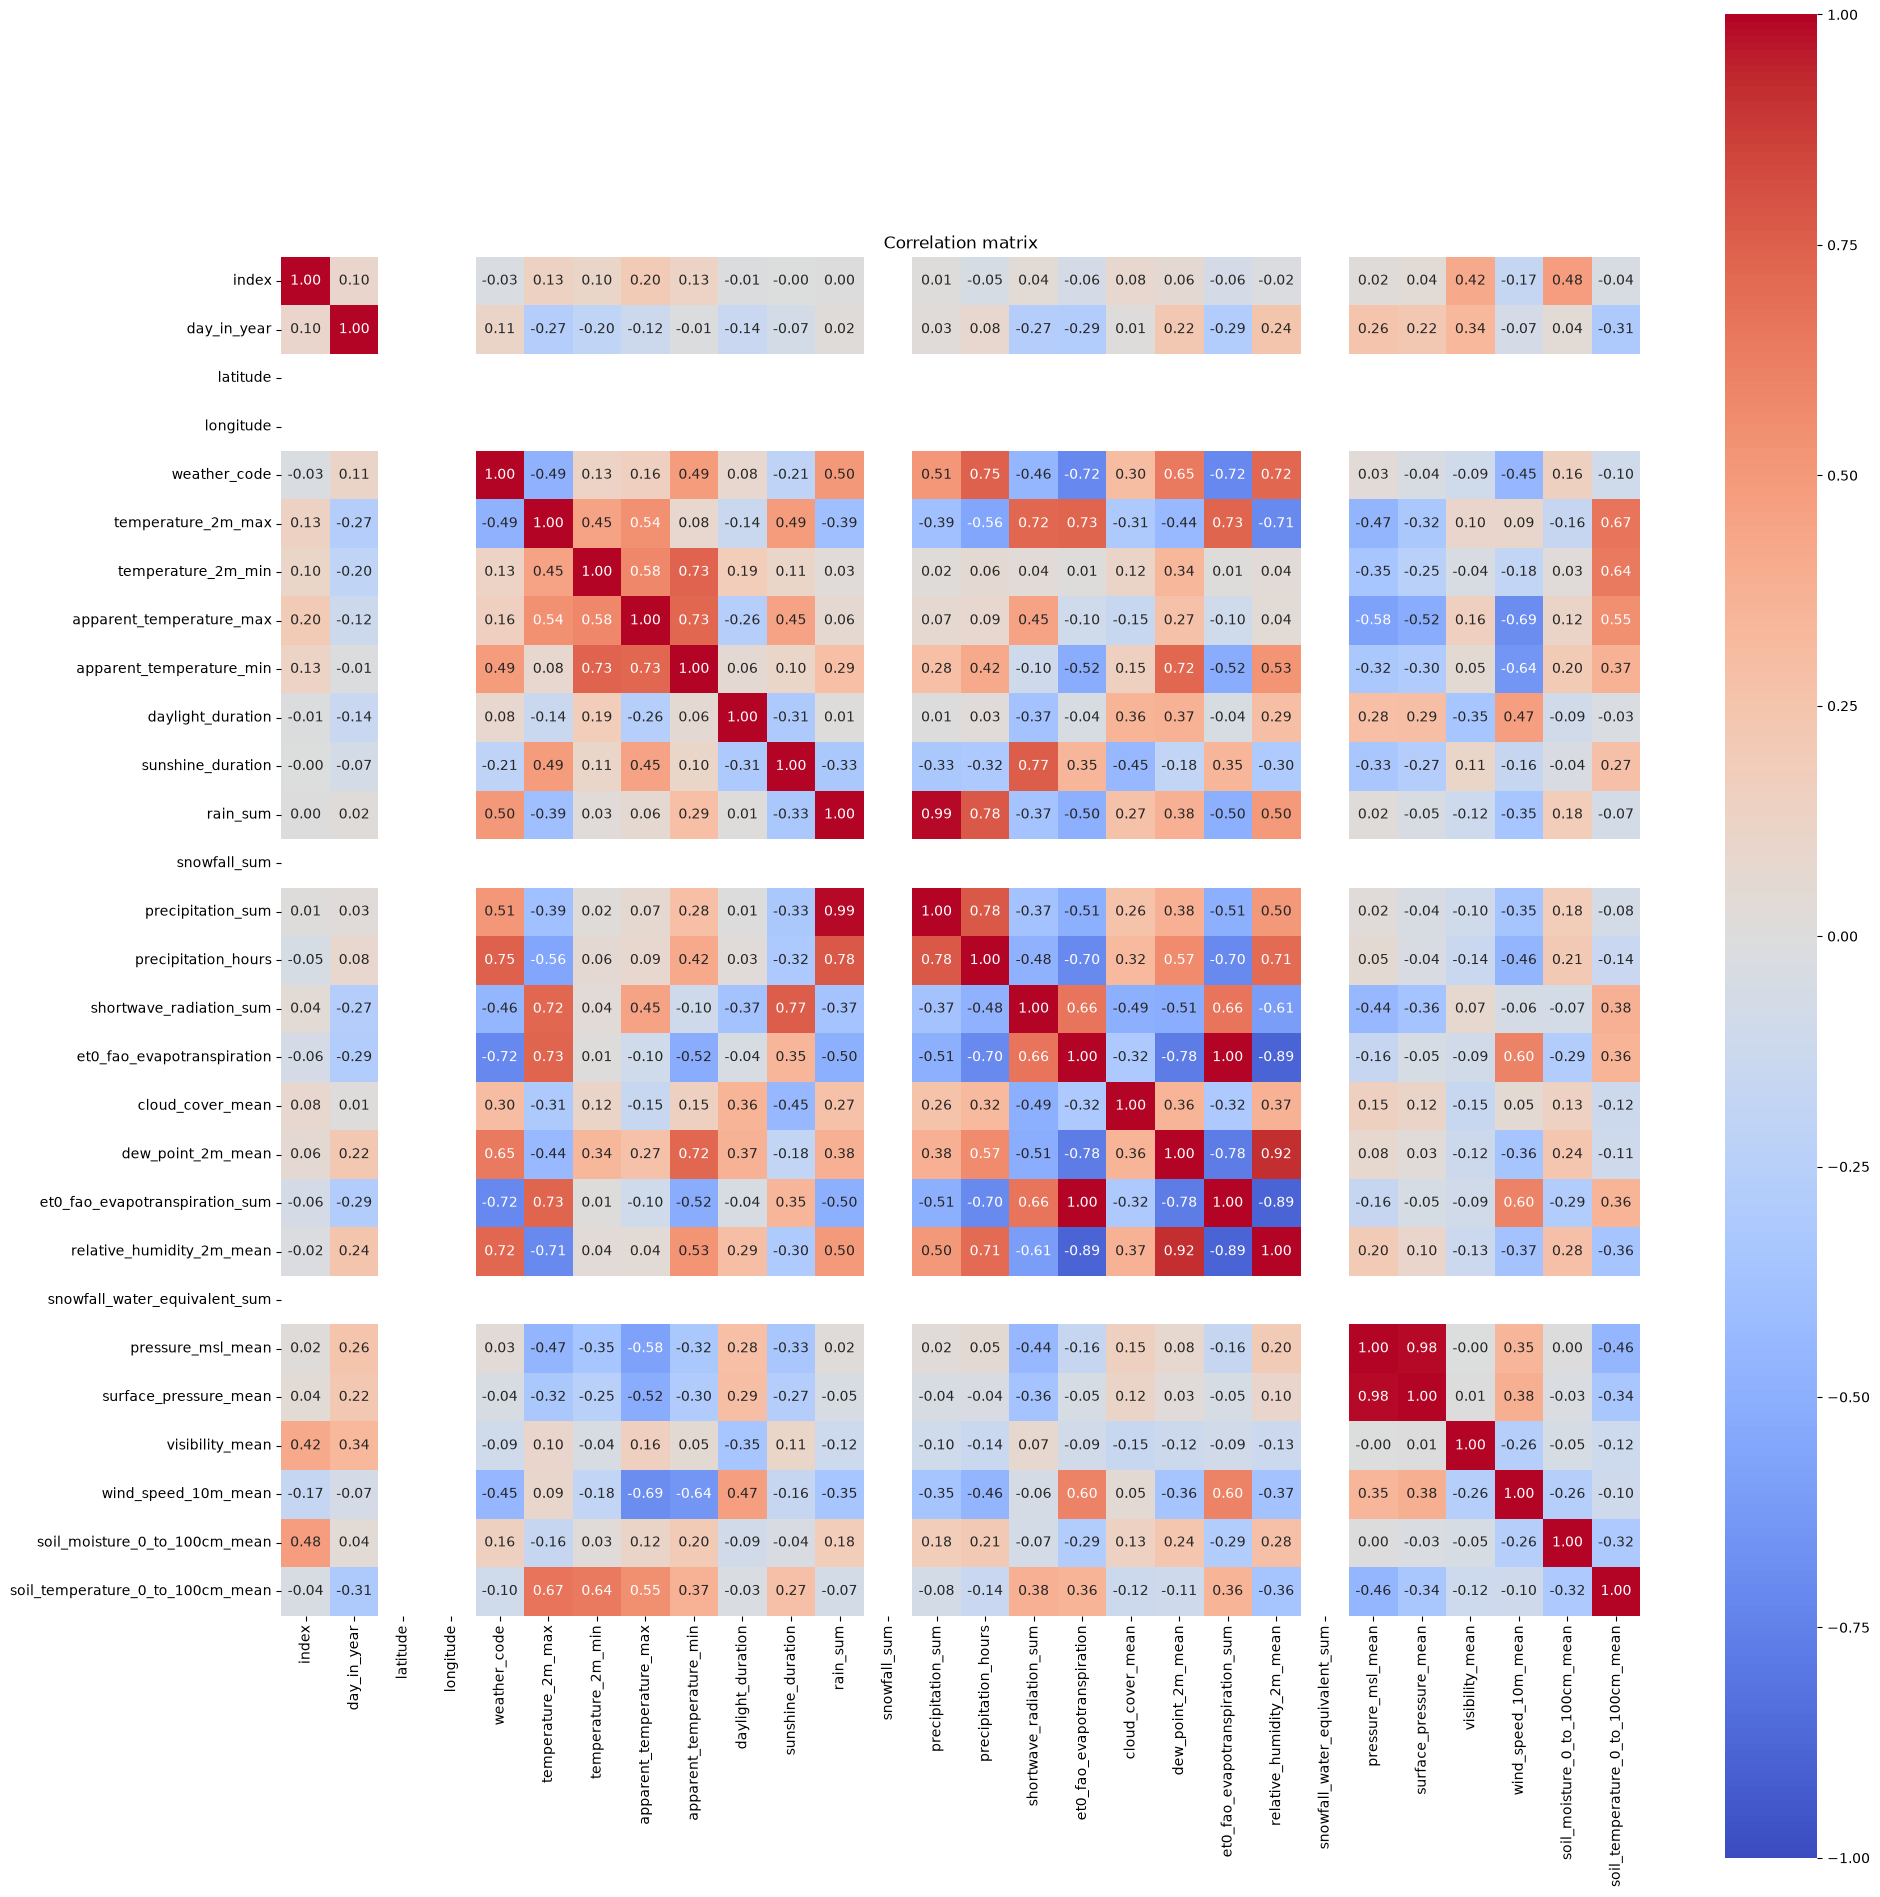

In [29]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()